

# Recreating the Master: World's Biggest Data Breaches & Hacks

**Name:** Bibek Thapa  
**Course:** CPSMA 4313 - Data Processing Visualization  
**Instructor:** Professor Nicholas Jacob  

## Project Goal

For this project, I am recreating the *World's Biggest Data Breaches & Hacks* visualization by Information is Beautiful. The original graphic is an interactive packed-bubble chart where each bubble represents a major data breach or hack. The bubble size represents the number of records lost, the vertical position organizes events by year, and the colors represent breach methods.

My final recreation focuses on matching the most important design features of the original visualization:

- packed bubbles
- bubble size based on records lost
- colors based on breach method
- vertical year scale
- search and filter controls
- hover details
- readable labels that scale with bubble size
- no unnecessary overlap between circles


## Original Visualization Reference

The original visualization is titled **World's Biggest Data Breaches & Hacks** and was created by **Information is Beautiful**.

**Original Visualization Link:**  
https://informationisbeautiful.net/visualizations/worlds-biggest-data-breaches-hacks/


The original visualization is excellent because it turns a large table of breach records into an exploratory visual system. Instead of asking the viewer to read every row, it uses circle size to communicate scale immediately. Larger breaches stand out visually, while smaller breaches still add density and context.

The vertical year axis helps show when breaches occurred, while color helps separate breach methods. The interactive search and filtering tools make the graphic useful for exploration, not just presentation.

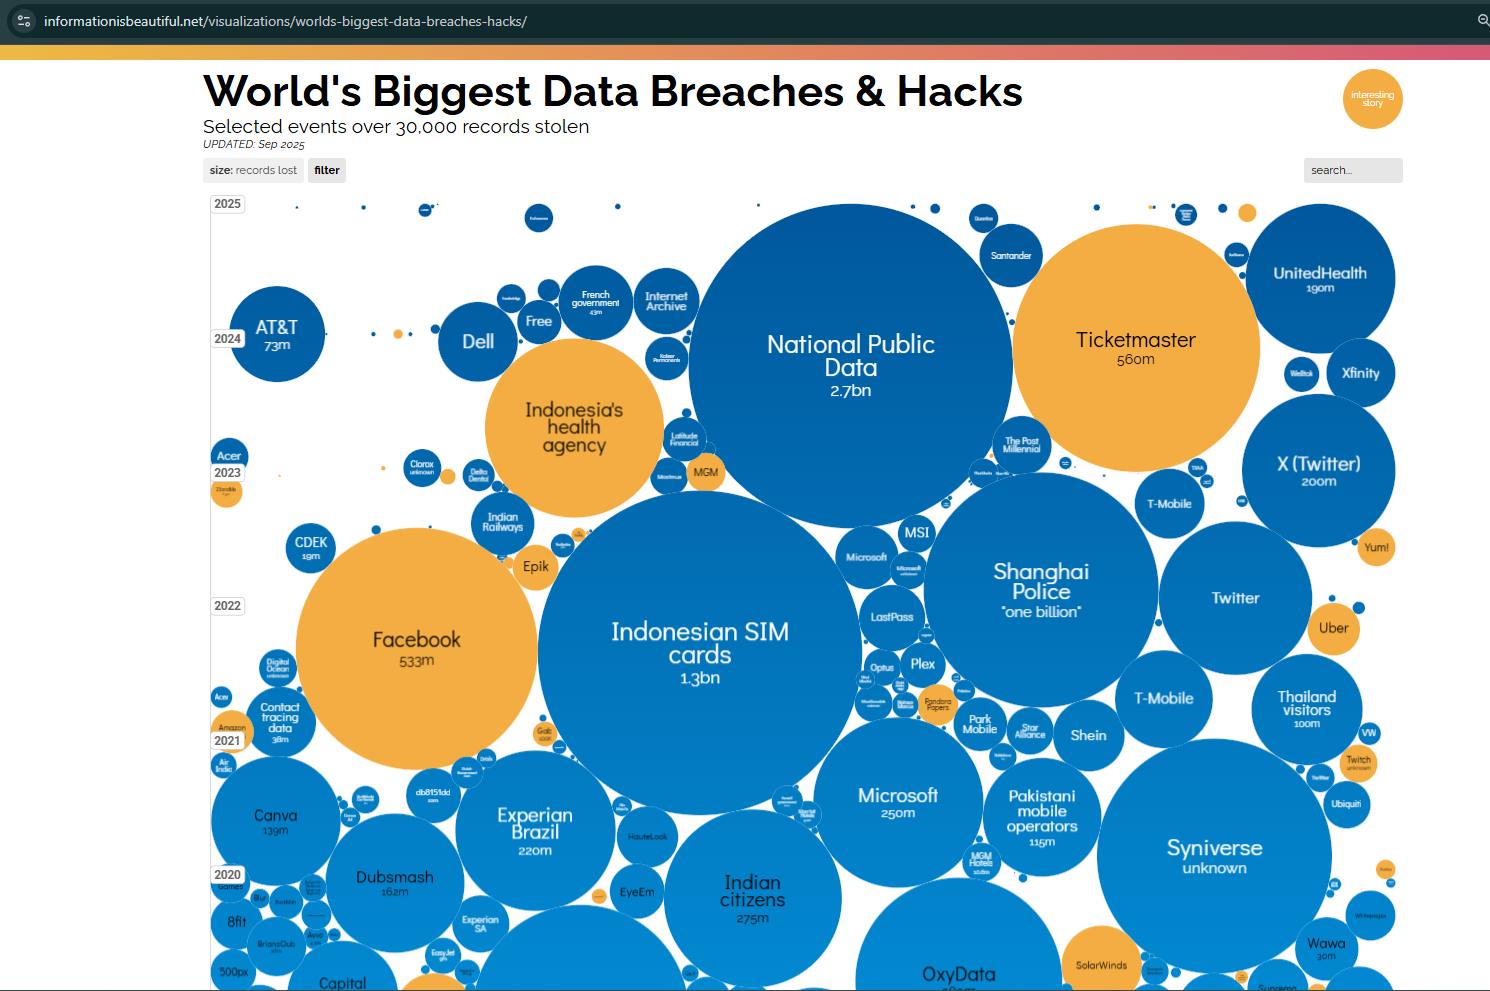

In [1]:
from IPython.display import Image, display

display(Image(filename="/content/original_visualization.png"))

In [2]:
# ------------------------------------------------------------
# PACKAGES
# ------------------------------------------------------------
# pandas: used to load and clean the dataset.
# numpy: used for missing values and numeric handling.
# json: used to pass cleaned Python data into the JavaScript/D3 visualization.
# pathlib: used to save and reuse a local copy of the dataset.
# IPython.display.HTML: used to render the final web/D3 visualization inside Jupyter.

import re
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display, HTML

## Package Explanation

The main Python packages used in this project are `pandas`, `numpy`, `json`, and `pathlib`.

No unusual Python visualization package is required because the final visualization is rendered using **D3.js**, a JavaScript visualization library. D3 is useful for this project because it supports force-based layouts, collision detection, SVG drawing, animation, and interactive controls. These features are important for recreating the packed-bubble behavior of the original website.

## Dataset Reference

The original visualization provides a public Google Sheet containing the source data.

**Dataset Link:**  
https://docs.google.com/spreadsheets/d/1i0oIJJMRG-7t1GT-mr4smaTTU7988yXVz8nPlwaJ8Xk/edit

The dataset includes information such as organization name, year, number of records lost, sector, breach method, data sensitivity, displayed records, and source information.

To avoid repeatedly reading the Google Sheet while editing the visualization, the notebook downloads the data once and saves it locally as `data_breaches_local.csv`. After the first run, the notebook loads from the local CSV file.

In [3]:
# ------------------------------------------------------------
# LOAD DATA LOCALLY
# ------------------------------------------------------------
# First run:
#   - Reads the public Google Sheet CSV.
#   - Saves a local copy as data_breaches_local.csv.
#
# Later runs:
#   - Loads from the local CSV file.
#   - This avoids repeatedly hitting the Google Sheet while editing the project.

SHEET_ID = "1i0oIJJMRG-7t1GT-mr4smaTTU7988yXVz8nPlwaJ8Xk"
GID = "2"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"

LOCAL_DATA_FILE = Path("data_breaches_local.csv")

try:
    if LOCAL_DATA_FILE.exists():
        df_raw = pd.read_csv(LOCAL_DATA_FILE)
        print(f"Loaded data from local file: {LOCAL_DATA_FILE}")
    else:
        df_raw = pd.read_csv(CSV_URL)
        df_raw.to_csv(LOCAL_DATA_FILE, index=False)
        print(f"Downloaded data once and saved locally as: {LOCAL_DATA_FILE}")

except Exception as e:
    raise RuntimeError(
        "Could not load the data. If the Google Sheet is blocked, download the CSV manually, "
        "save it as data_breaches_local.csv in the same notebook folder, and rerun this cell.\n"
        f"Original error: {e}"
    )

print("Raw shape:", df_raw.shape)
print("Raw columns:")
print(list(df_raw.columns))

display(df_raw.head())

Loaded data from local file: data_breaches_local.csv
Raw shape: (521, 16)
Raw columns:
['organisation', 'alternative name', 'records lost', 'year   ', 'date', 'story', 'sector', 'method', 'interesting story', 'data sensitivity', 'displayed records', 'Unnamed: 11', 'source name', '1st source link', '2nd source link', 'ID']


,organisation,alternative name,records lost,year,date,story,sector,method,interesting story,data sensitivity,displayed records,Unnamed: 11,source name,1st source link,2nd source link,ID
0,visualisation here: https://informationisbeaut...,NaN,"(use 3m, 4m, 5m or 10m to approximate unknown ...",year story broke,NaN,NaN,NaN,poor security\nhacked\noops!\nlost device \nin...,NaN,1. Just email address/Online information \n2 S...,NaN,NaN,NaN,NaN,NaN,NaN
1,Quantas,NaN,"5,700,000",2025,Jul 25,The records of nearly 6 million customers on t...,transport,hacked,NaN,2,NaN,NaN,ABC,https://www.abc.net.au/news/2025-07-02/qantas-...,NaN,524.0
2,GiveSendGo,NaN,"92,000",2022,Feb 22,Crowdfunding site that raised funds for the an...,web,hacked,y,2,NaN,NaN,Vice,https://www.vice.com/en/article/freedom-convoy...,NaN,523.0
3,Tea,NaN,"72,000",2025,Jul 25,Web service providing safety for women online ...,web,hacked,y,4,NaN,NaN,Tech Crunch,https://techcrunch.com/2025/07/26/dating-safet...,NaN,522.0
4,Lee Enterprises,NaN,"39,000",2025,Feb 25,Attackers behind a ransomware attack in Feb al...,misc,hacked,NaN,2,NaN,NaN,Beeping Computer,https://www.bleepingcomputer.com/news/security...,NaN,521.0


## Data Cleaning

The raw dataset needs cleaning before it can be used in the visualization.

The cleaning process includes:

1. Standardizing column names so the notebook can reliably identify fields such as organization, year, records lost, sector, and method.
2. Converting the `records lost` field into a numeric value so bubble sizes can be calculated.
3. Converting year values into integers so the vertical year scale can be built correctly.
4. Filling missing sector and method values with `"unknown"` so every bubble has a category and color.
5. Removing rows that do not have the required values needed for the visualization.
6. Creating a readable display value such as `533m`, `1.3bn`, or `250m` for bubble labels and hover text.

In [4]:
# ------------------------------------------------------------
# CLEANING HELPER FUNCTIONS
# ------------------------------------------------------------

def clean_column_name(col):
    """
    Standardizes column names by making them lowercase,
    removing line breaks, and reducing repeated spaces.
    """
    col = str(col).strip().lower().replace("\n", " ")
    col = re.sub(r"\s+", " ", col)
    return col


def normalize_category(value):
    """
    Cleans category values such as sector and method.
    Missing or blank values are converted to 'unknown'.
    """
    if pd.isna(value):
        return "unknown"

    value = str(value).strip().lower()
    value = re.sub(r"\s+", " ", value)

    if value in ["", "nan", "none", "null", "n/a"]:
        return "unknown"

    return value


def to_number(value):
    """
    Converts record counts into numeric values.
    This is necessary because bubble size depends on records lost.
    """
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()
    s = s.replace(",", "")
    s = s.replace("~", "")
    s = s.replace("+", "")
    s = s.replace("'", "")
    s = s.replace('"', "")
    s = s.replace(" ", "")

    if s in ["", "unknown", "nan", "none", "null", "n/a"]:
        return np.nan

    filtered = "".join(ch for ch in s if ch.isdigit() or ch in [".", "-", "e", "E"])

    try:
        return float(filtered)
    except Exception:
        return np.nan


def human_records(n):
    """
    Converts numeric record counts into readable labels.
    Example:
    533000000 -> 533m
    1300000000 -> 1.3bn
    """
    if pd.isna(n):
        return "unknown"

    n = float(n)

    if n >= 1_000_000_000:
        val = n / 1_000_000_000
        return f"{val:.1f}bn" if val < 10 else f"{val:.0f}bn"

    if n >= 1_000_000:
        val = n / 1_000_000
        return f"{val:.0f}m" if val >= 10 else f"{val:.1f}m"

    if n >= 1_000:
        val = n / 1_000
        return f"{val:.0f}k" if val >= 10 else f"{val:.1f}k"

    return f"{int(n)}"

In [5]:
# ------------------------------------------------------------
# CLEAN DATASET
# ------------------------------------------------------------

df = df_raw.copy()

# Standardize column names.
df.columns = [clean_column_name(c) for c in df.columns]

# Map possible source column names to stable names.
col_map = {}

for c in df.columns:
    c_clean = c.strip().lower()

    if c_clean in ["organisation", "organization", "org", "company", "entity"]:
        col_map[c] = "organisation"

    elif c_clean in ["records lost", "records_lost", "records", "breached records"]:
        col_map[c] = "records_lost"

    elif c_clean in ["year", "breach year"]:
        col_map[c] = "year"

    elif c_clean in ["sector", "industry"]:
        col_map[c] = "sector"

    elif c_clean in ["method", "breach method"]:
        col_map[c] = "method"

    elif c_clean in ["story", "description", "details"]:
        col_map[c] = "story"

    elif c_clean in ["displayed records", "displayed_records", "display records"]:
        col_map[c] = "displayed_records"

    elif c_clean in ["data sensitivity", "sensitivity"]:
        col_map[c] = "data_sensitivity"

    elif c_clean in ["source", "source name"]:
        col_map[c] = "source"

    elif c_clean in ["1st source link", "first source link", "source link 1", "source 1 link"]:
        col_map[c] = "source_url_1"

    elif c_clean in ["2nd source link", "second source link", "source link 2", "source 2 link"]:
        col_map[c] = "source_url_2"

    elif c_clean in [
        "source link",
        "source url",
        "link",
        "url",
        "article",
        "article link",
        "article url"
    ]:
        col_map[c] = "source_url"

    elif c_clean in ["date", "breach date"]:
        col_map[c] = "date"

df = df.rename(columns=col_map)

required = ["organisation", "records_lost", "year"]
missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}\n"
        f"Available columns: {list(df.columns)}"
    )

# Add optional columns if they are missing.
for optional in [
    "sector",
    "method",
    "story",
    "displayed_records",
    "data_sensitivity",
    "source",
    "source_url",
    "source_url_1",
    "source_url_2",
    "date"
]:
    if optional not in df.columns:
        df[optional] = ""


def clean_optional_text(value):
    """
    Safely cleans optional text fields without converting real NaN into 'nan'.
    """
    if pd.isna(value):
        return ""

    value = str(value).strip()

    if value.lower() in ["", "nan", "none", "null", "n/a"]:
        return ""

    return value


def extract_first_url(value):
    """
    Extracts the first URL from a text value.
    If the cell already contains only a URL, it returns that URL.
    """
    if pd.isna(value):
        return ""

    text = str(value).strip()

    match = re.search(r"https?://[^\s,\]\)\"']+", text)

    if match:
        return match.group(0)

    return ""


# Clean required fields.
df["organisation"] = df["organisation"].apply(clean_optional_text)
df["records_lost"] = df["records_lost"].apply(to_number)
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Clean category fields.
df["sector"] = df["sector"].apply(normalize_category)
df["method"] = df["method"].apply(normalize_category)

# Clean optional text fields.
df["story"] = df["story"].apply(clean_optional_text)
df["displayed_records"] = df["displayed_records"].apply(clean_optional_text)
df["data_sensitivity"] = df["data_sensitivity"].apply(clean_optional_text)
df["source"] = df["source"].apply(clean_optional_text)

# Clean source URL fields.
df["source_url"] = df["source_url"].apply(clean_optional_text)
df["source_url_1"] = df["source_url_1"].apply(clean_optional_text)
df["source_url_2"] = df["source_url_2"].apply(clean_optional_text)

# Prefer 1st source link.
# If blank, use 2nd source link.
# If both blank, use general source_url.
df["final_source_url"] = np.where(
    df["source_url_1"].str.len() > 0,
    df["source_url_1"],
    np.where(
        df["source_url_2"].str.len() > 0,
        df["source_url_2"],
        df["source_url"]
    )
)

# Extract clean URL from the chosen source field.
df["final_source_url"] = df["final_source_url"].apply(extract_first_url)

# Remove rows that cannot be plotted.
df = df.dropna(subset=["organisation", "records_lost", "year"]).copy()
df = df[df["organisation"].str.len() > 0].copy()
df = df[df["records_lost"] > 0].copy()

# Convert year to integer.
df["year"] = df["year"].astype(int)

# Keep a reasonable year range.
df = df[(df["year"] >= 2004) & (df["year"] <= 2030)].copy()

# Remove duplicated breach entries.
df = df.drop_duplicates(subset=["organisation", "year", "records_lost"]).copy()

# Create readable display values for labels and tooltips.
# Use displayed_records only when it is real text, not blank/nan/null.
df["display_value"] = np.where(
    df["displayed_records"].apply(
        lambda x: str(x).strip().lower() not in ["", "nan", "none", "null", "n/a"]
    ),
    df["displayed_records"],
    df["records_lost"].apply(human_records)
)

print("Cleaned shape:", df.shape)
print("Rows with final source URLs:", (df["final_source_url"].str.len() > 0).sum())

display(df.head(10))
display(df[["organisation", "source", "source_url_1", "source_url_2", "final_source_url"]].head(10))

Cleaned shape: (520, 19)
Rows with final source URLs: 519


,organisation,alternative name,records_lost,year,date,story,sector,method,interesting story,data_sensitivity,displayed_records,unnamed: 11,source,source_url_1,source_url_2,id,source_url,final_source_url,display_value
1,Quantas,NaN,5700000.0,2025,Jul 25,The records of nearly 6 million customers on t...,transport,hacked,NaN,2,,NaN,ABC,https://www.abc.net.au/news/2025-07-02/qantas-...,,524.0,,https://www.abc.net.au/news/2025-07-02/qantas-...,5.7m
2,GiveSendGo,NaN,92000.0,2022,Feb 22,Crowdfunding site that raised funds for the an...,web,hacked,y,2,,NaN,Vice,https://www.vice.com/en/article/freedom-convoy...,,523.0,,https://www.vice.com/en/article/freedom-convoy...,92k
3,Tea,NaN,72000.0,2025,Jul 25,Web service providing safety for women online ...,web,hacked,y,4,,NaN,Tech Crunch,https://techcrunch.com/2025/07/26/dating-safet...,,522.0,,https://techcrunch.com/2025/07/26/dating-safet...,72k
4,Lee Enterprises,NaN,39000.0,2025,Feb 25,Attackers behind a ransomware attack in Feb al...,misc,hacked,NaN,2,,NaN,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,521.0,,https://www.bleepingcomputer.com/news/security...,39k
5,Cartier,NaN,100000.0,2025,Jun 25,Luxury fashion brand Cartier warned customers ...,retail,hacked,NaN,1,,NaN,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,520.0,,https://www.bleepingcomputer.com/news/security...,100k
6,The North Face,NaN,100000.0,2025,Apr 25,The North Face is warning customers that their...,retail,hacked,NaN,2,,NaN,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,519.0,,https://www.bleepingcomputer.com/news/security...,100k
7,LexisNexis,NaN,364000.0,2024,Dec 24,Data broker giant LexisNexis Risk Solutions st...,tech,poor security,NaN,2,,NaN,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,518.0,,https://www.bleepingcomputer.com/news/security...,364k
8,Adidas,NaN,100000.0,2025,May 25,German sportswear giant Adidas disclosed attac...,retail,hacked,NaN,1,,NaN,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,517.0,,https://www.bleepingcomputer.com/news/security...,100k
9,Coinbase,NaN,69461.0,2025,May 25,"Coinbase said, ""individuals performing service...",finance,inside job,NaN,3,,NaN,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,516.0,,https://www.bleepingcomputer.com/news/security...,69k
10,UK's Legal Aid Agency,LAA,2100000.0,2025,May 25,"Criminal records dating back to 2010, as well ...",government,hacked,y,3,,NaN,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,515.0,,https://www.bleepingcomputer.com/news/security...,2.1m


,organisation,source,source_url_1,source_url_2,final_source_url
1,Quantas,ABC,https://www.abc.net.au/news/2025-07-02/qantas-...,,https://www.abc.net.au/news/2025-07-02/qantas-...
2,GiveSendGo,Vice,https://www.vice.com/en/article/freedom-convoy...,,https://www.vice.com/en/article/freedom-convoy...
3,Tea,Tech Crunch,https://techcrunch.com/2025/07/26/dating-safet...,,https://techcrunch.com/2025/07/26/dating-safet...
4,Lee Enterprises,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,https://www.bleepingcomputer.com/news/security...
5,Cartier,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,https://www.bleepingcomputer.com/news/security...
6,The North Face,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,https://www.bleepingcomputer.com/news/security...
7,LexisNexis,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,https://www.bleepingcomputer.com/news/security...
8,Adidas,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,https://www.bleepingcomputer.com/news/security...
9,Coinbase,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,https://www.bleepingcomputer.com/news/security...
10,UK's Legal Aid Agency,Beeping Computer,https://www.bleepingcomputer.com/news/security...,,https://www.bleepingcomputer.com/news/security...


## Visual Encoding

The final recreation uses the following visual encodings:

- **Bubble size:** number of records lost
- **Vertical position:** year of breach
- **Color:** breach method
- **Hover tooltip:** organization, records lost, sector, method, sensitivity, and story
- **Search/filter controls:** allow the viewer to focus on specific sectors, methods, years, or organizations

The color palette is inspired by the original visualization. Most cyber/hacking events are blue, while security mistakes and accidental leaks use orange/yellow tones.

In [6]:
# ------------------------------------------------------------
# COLOR ENCODING
# ------------------------------------------------------------
# Website-inspired method colors.
# The original visual style is mostly blue with orange/yellow contrast.

METHOD_COLORS = {
    "hacked": "#0789C9",
    "poor security": "#F5B23A",
    "oops!": "#F2A23A",
    "lost device": "#F6CD7A",
    "inside job": "#73B6D8",
    "unknown": "#B8D4E8",
}


def color_for_method(method):
    return METHOD_COLORS.get(normalize_category(method), "#B8D4E8")


df["color"] = df["method"].apply(color_for_method)

display(df[["organisation", "year", "records_lost", "display_value", "sector", "method", "color"]].head(10))

,organisation,year,records_lost,display_value,sector,method,color
1,Quantas,2025,5700000.0,5.7m,transport,hacked,#0789C9
2,GiveSendGo,2022,92000.0,92k,web,hacked,#0789C9
3,Tea,2025,72000.0,72k,web,hacked,#0789C9
4,Lee Enterprises,2025,39000.0,39k,misc,hacked,#0789C9
5,Cartier,2025,100000.0,100k,retail,hacked,#0789C9
6,The North Face,2025,100000.0,100k,retail,hacked,#0789C9
7,LexisNexis,2024,364000.0,364k,tech,poor security,#F5B23A
8,Adidas,2025,100000.0,100k,retail,hacked,#0789C9
9,Coinbase,2025,69461.0,69k,finance,inside job,#73B6D8
10,UK's Legal Aid Agency,2025,2100000.0,2.1m,government,hacked,#0789C9


## Preparing Data for D3

The final visualization is drawn with D3.js inside the notebook. Before sending the data into D3, the cleaned pandas DataFrame is converted into a list of dictionaries.

This step is necessary because JavaScript can easily read JSON-style data. Each dictionary represents one breach bubble and includes the organization name, year, records lost, method, sector, story, display value, and color.

In [7]:
# ------------------------------------------------------------
# PREPARE DATA FOR D3
# ------------------------------------------------------------
# Convert the cleaned pandas DataFrame into JSON-friendly records.
# These records will be passed into the D3 JavaScript visualization.

records = []

for _, row in df.iterrows():
    records.append({
        "organisation": str(row["organisation"]),
        "records_lost": float(row["records_lost"]),
        "display_value": str(row["display_value"]),
        "year": int(row["year"]),
        "sector": str(row["sector"]),
        "method": str(row["method"]),
        "story": str(row.get("story", "")),
        "data_sensitivity": str(row.get("data_sensitivity", "")),
        "source": str(row.get("source", "")),
        "source_url": str(row.get("final_source_url", "")),
        "color": str(row["color"]),
    })

json_data = json.dumps(records)

min_year = int(df["year"].min())
max_year = int(df["year"].max())

sectors_json = json.dumps(sorted(df["sector"].dropna().unique().tolist()))
methods_json = json.dumps(sorted(df["method"].dropna().unique().tolist()))

print("Number of records prepared for D3:", len(records))
print("Year range:", min_year, "to", max_year)
print("Records with source URLs:", sum(1 for r in records if r["source_url"].strip()))

# Quick check.
display(pd.DataFrame(records)[["organisation", "source", "source_url"]].head(10))

Number of records prepared for D3: 520
Year range: 2004 to 2025
Records with source URLs: 519


,organisation,source,source_url
0,Quantas,ABC,https://www.abc.net.au/news/2025-07-02/qantas-...
1,GiveSendGo,Vice,https://www.vice.com/en/article/freedom-convoy...
2,Tea,Tech Crunch,https://techcrunch.com/2025/07/26/dating-safet...
3,Lee Enterprises,Beeping Computer,https://www.bleepingcomputer.com/news/security...
4,Cartier,Beeping Computer,https://www.bleepingcomputer.com/news/security...
5,The North Face,Beeping Computer,https://www.bleepingcomputer.com/news/security...
6,LexisNexis,Beeping Computer,https://www.bleepingcomputer.com/news/security...
7,Adidas,Beeping Computer,https://www.bleepingcomputer.com/news/security...
8,Coinbase,Beeping Computer,https://www.bleepingcomputer.com/news/security...
9,UK's Legal Aid Agency,Beeping Computer,https://www.bleepingcomputer.com/news/security...


## CSS Styling

The CSS is separated into its own cell because most of the visual tuning happens here. This includes the page header, controls, filter panel, legend, bubble appearance, year labels, tooltip, and chart spacing.

Separating CSS makes the notebook easier to edit because visual changes can be made without changing the data-cleaning code or the D3 layout logic.

In [8]:
# ------------------------------------------------------------
# CSS STYLES
# ------------------------------------------------------------


CSS_STYLES = """
<style>
  .breach-app {
    font-family: Arial, Helvetica, sans-serif;
    background: #ffffff;
    border: 1px solid #dddddd;
    border-radius: 4px;
    overflow: visible;
    width: 100%;
    max-width: 835px;
    color: #111;
  }

  .top-gradient {
    display: none;
  }

  .header-row {
    display: flex;
    justify-content: space-between;
    align-items: flex-start;
    padding: 8px 42px 2px 42px;
  }

  .header-row h1 {
    margin: 0;
    font-size: 36px;
    line-height: 1.03;
    font-weight: 900;
    letter-spacing: -1.2px;
  }

  .subtitle {
    font-size: 16px;
    margin-top: 0;
  }

  .updated {
    font-size: 10px;
    font-style: italic;
    color: #333;
    margin-top: 1px;
  }

  .story-badge {
    background: #f2a832;
    color: white;
    width: 50px;
    height: 50px;
    border-radius: 50%;
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 7px;
    text-align: center;
    line-height: 1.1;
    margin-top: 1px;
  }

  .controls-bar {
    display: flex;
    align-items: center;
    gap: 4px;
    padding: 4px 42px;
    position: relative;
  }

  .control-box {
    background: #eeeeee;
    border-radius: 2px;
    padding: 4px 6px;
    font-size: 10px;
  }

  .control-box select {
    border: none;
    background: transparent;
    font-size: 10px;
  }

  .filter-button,
  .apply-button,
  .reset-button {
    background: #e8ecef;
    border: none;
    border-radius: 2px;
    padding: 6px 8px;
    font-size: 10px;
    font-weight: 700;
    cursor: pointer;
  }

  .filter-button:hover,
  .reset-button:hover {
    background: #dce3e8;
  }

  .apply-button {
    background: #111111;
    color: #ffffff;
  }

  .apply-button:hover {
    background: #333333;
  }

  .search-box {
    position: absolute;
    right: 42px;
    top: 4px;
    width: 105px;
    background: #e6e6e6;
    border: none;
    border-radius: 2px;
    padding: 6px 8px;
    font-size: 10px;
  }

  .filter-panel {
    display: none;
    margin: 4px 42px 2px 42px;
    background: #f2f2f2;
    border: 1px solid #d8d8d8;
    border-radius: 4px;
    padding: 8px;
    gap: 10px;
    align-items: flex-end;
    flex-wrap: wrap;
  }

  .filter-panel.open {
    display: flex;
  }

  .filter-group {
    display: flex;
    flex-direction: column;
    gap: 2px;
    font-size: 10px;
  }

  .filter-group label {
    font-weight: 700;
    color: #444;
  }

  .filter-group select,
  .filter-group input {
    font-size: 11px;
    padding: 4px;
    border: 1px solid #cfcfcf;
    border-radius: 3px;
    min-width: 130px;
  }

  .small-filter input {
    min-width: 70px;
    width: 70px;
  }

  .legend-row {
    padding: 2px 42px 0 42px;
    font-size: 11px;
    color: #444;
    display: flex;
    gap: 13px;
    align-items: center;
    flex-wrap: wrap;
  }

  .legend-row .note {
    margin-left: auto;
    color: #777;
    font-style: italic;
  }

  .dot {
    display: inline-block;
    width: 9px;
    height: 9px;
    border-radius: 50%;
    margin-right: 4px;
  }

  .dot.hacked { background: #0789C9; }
  .dot.poor { background: #F5B23A; }
  .dot.oops { background: #F2A23A; }
  .dot.lost { background: #F6CD7A; }
  .dot.inside { background: #73B6D8; }
  .dot.unknown { background: #B8D4E8; }

  .chart-wrap {
    position: relative;
    margin: 0 42px 0 42px;
    min-height: 760px;
    height: auto;
    overflow: visible;
    background: #ffffff;
  }

  #breachSvg {
    width: 100%;
    min-height: 760px;
    display: block;
    background: #ffffff;
    overflow: visible;
  }

  .bubble {
    stroke: white;
    stroke-width: 1.2px;
    cursor: pointer;
  }

  .bubble:hover {
    stroke: #111;
    stroke-width: 2.3px;
  }

  .bubble-label {
    pointer-events: none;
    text-anchor: middle;
    dominant-baseline: middle;
    font-weight: 800;
    fill: white;
  }

  .bubble-value {
    pointer-events: none;
    text-anchor: middle;
    dominant-baseline: middle;
    font-weight: 600;
    fill: white;
  }

  .bubble-label.dark,
  .bubble-value.dark {
    fill: #222;
  }

  .year-tag {
    fill: #ffffff;
    stroke: #cccccc;
    stroke-width: 1;
  }

  .year-text {
    fill: #666666;
    font-size: 10px;
    font-weight: 700;
  }

  .axis-line {
    stroke: #cccccc;
    stroke-width: 1;
  }

  .tooltip {
    position: absolute;
    display: none;
    pointer-events: none;
    background: rgba(255, 255, 255, 0.97);
    border: 1px solid #cfcfcf;
    border-radius: 8px;
    padding: 9px 10px;
    width: 260px;
    box-shadow: 0 4px 18px rgba(0,0,0,0.16);
    font-size: 12px;
    line-height: 1.35;
    z-index: 10;
  }

  .tooltip strong {
    font-size: 14px;
  }

  .status-line {
    padding: 8px 42px 14px 42px;
    font-size: 12px;
    color: #555;
  }
</style>
"""

## HTML Structure

The HTML creates the container for the recreation. It includes the title, subtitle, update note, search box, filter panel, legend, SVG chart area, tooltip, and status line.

The actual bubbles are not written manually in the HTML. They are generated dynamically by D3 in the next JavaScript section.

In [9]:
# ------------------------------------------------------------
# HTML STRUCTURE
# ------------------------------------------------------------
# This creates the visible layout of the final visualization.
# D3 will draw the bubbles inside the <svg id="breachSvg"></svg> element.

HTML_STRUCTURE = f"""
<div id="breach-app-final" class="breach-app">
  <div class="top-gradient">
    New! Learn to do data-viz with our online seminars.
    <span>Find Out More</span>
  </div>

  <div class="header-row">
    <div>
      <h1>World's Biggest Data Breaches & Hacks</h1>
      <div class="subtitle">Selected events over 30,000 records stolen</div>
      <div class="updated">UPDATED: Sep 2025</div>
    </div>
    <div class="story-badge">Interesting<br>story</div>
  </div>

  <div class="controls-bar">
    <div class="control-box">
      <label>size:</label>
      <select id="sizeSelect">
        <option value="records_lost" selected>records lost</option>
      </select>
    </div>

    <button id="filterButton" class="filter-button">filter</button>
    <input id="searchBox" class="search-box" type="text" placeholder="search...">
  </div>

  <div id="filterPanel" class="filter-panel">
    <div class="filter-group">
      <label>Sector</label>
      <select id="sectorSelect">
        <option value="all">All sectors</option>
      </select>
    </div>

    <div class="filter-group">
      <label>Method</label>
      <select id="methodSelect">
        <option value="all">All methods</option>
      </select>
    </div>

    <div class="filter-group small-filter">
      <label>From</label>
      <input id="fromYear" type="number" value="2020" min="{min_year}" max="{max_year}">
    </div>

    <div class="filter-group small-filter">
      <label>To</label>
      <input id="toYear" type="number" value="{max_year}" min="{min_year}" max="{max_year}">
    </div>

    <div class="filter-group small-filter">
      <label>Top N</label>
      <input id="topN" type="number" value="120" min="20" max="250" step="10">
    </div>

    <button id="applyFilterButton" class="apply-button">apply filter</button>
    <button id="resetButton" class="reset-button">reset</button>
  </div>

  <div class="legend-row">
    <span><i class="dot hacked"></i> hacked</span>
    <span><i class="dot poor"></i> poor security</span>
    <span><i class="dot oops"></i> oops!</span>
    <span><i class="dot lost"></i> lost device</span>
    <span><i class="dot inside"></i> inside job</span>
    <span><i class="dot unknown"></i> unknown</span>
    <span class="note">Hover over bubbles for details</span>
  </div>

  <div id="chartWrap" class="chart-wrap">
    <svg id="breachSvg"></svg>
    <div id="tooltip" class="tooltip"></div>
  </div>

  <div id="statusLine" class="status-line"></div>
</div>
"""

In [10]:
# ------------------------------------------------------------
# JAVASCRIPT DATA INJECTION
# ------------------------------------------------------------
# Keeping this separate lets the main D3 script stay as a normal string.
# That avoids Python f-string errors caused by JavaScript curly braces.

JS_DATA_SCRIPT = f"""
<script>
window.__BREACH_RAW_DATA__ = {json_data};
window.__BREACH_SECTORS__ = {sectors_json};
window.__BREACH_METHODS__ = {methods_json};
window.__BREACH_MAX_YEAR__ = {max_year};
</script>
"""

## D3 Visualization Logic

The D3 script creates the packed-bubble visualization. The code performs several important tasks:

1. Builds the sector and method filter menus.
2. Filters the data based on search, year range, sector, method, and top N.
3. Creates a vertical year scale similar to the original graphic.
4. Uses square-root scaling so bubble area represents records lost.
5. Uses D3 force simulation to pack the bubbles.
6. Uses collision detection so circles do not print on top of each other.
7. Uses boundary force so bubbles do not cross the year axis.
8. Adds animated bubble entry so the largest bubbles appear first.
9. Dynamically scales labels so text fits better inside the bubbles.
10. Adds hover tooltips for detailed information.

In [11]:
D3_SCRIPT = """
<script src="https://cdn.jsdelivr.net/npm/d3@7"></script>
<script>
(function() {
  const rawData = window.__BREACH_RAW_DATA__;
  const sectors = window.__BREACH_SECTORS__;
  const methods = window.__BREACH_METHODS__;
  const maxYear = window.__BREACH_MAX_YEAR__;

  const app = document.getElementById("breach-app-final");
  const svg = d3.select(app).select("#breachSvg");
  const tooltip = d3.select(app).select("#tooltip");
  const statusLine = d3.select(app).select("#statusLine");

  const sectorSelect = app.querySelector("#sectorSelect");
  const methodSelect = app.querySelector("#methodSelect");
  const searchBox = app.querySelector("#searchBox");
  const fromYear = app.querySelector("#fromYear");
  const toYear = app.querySelector("#toYear");
  const topN = app.querySelector("#topN");
  const filterButton = app.querySelector("#filterButton");
  const filterPanel = app.querySelector("#filterPanel");
  const applyFilterButton = app.querySelector("#applyFilterButton");
  const resetButton = app.querySelector("#resetButton");
  const chartWrap = app.querySelector("#chartWrap");

  // ------------------------------------------------------------
  // COMPACT VIEW SETTINGS
  // ------------------------------------------------------------
  const COMPACT_MAX_WIDTH = 835;
  const COMPACT_MIN_HEIGHT = 840;
  const OUTER_SAFE_WIDTH = "min(" + COMPACT_MAX_WIDTH + "px, calc(100vw - 16px))";

  // ------------------------------------------------------------
  // CSS FIXES
  // ------------------------------------------------------------
  if (!document.getElementById("breachStyleOverrides")) {
    const style = document.createElement("style");
    style.id = "breachStyleOverrides";
    style.innerHTML = `
      #topGradientBorderOnly {
        width: min(835px, calc(100vw - 16px)) !important;
        max-width: 835px !important;
        height: 42px !important;
        margin: 0 auto !important;
        background: linear-gradient(90deg, #f6cb32 0%, #f0a345 35%, #d95874 75%, #c64682 100%) !important;
        border-bottom: 1px solid rgba(0,0,0,0.06) !important;
        box-sizing: border-box !important;
        display: block !important;
      }

      #breach-app-final {
        width: min(835px, calc(100vw - 16px)) !important;
        max-width: 835px !important;
        margin: 0 auto !important;
        color: #000000 !important;
        font-family: Arial, Helvetica, sans-serif !important;
        overflow: visible !important;
        box-sizing: border-box !important;
      }

      #breach-app-final .header-row {
        padding-left: 42px !important;
        padding-right: 42px !important;
      }

      #breach-app-final h1,
      #breach-app-final .title,
      #breach-app-final .main-title {
        color: #000000 !important;
        font-weight: 900 !important;
      }

      #breach-app-final h2,
      #breach-app-final .subtitle,
      #breach-app-final .sub-title {
        color: #000000 !important;
      }

      #breach-app-final small,
      #breach-app-final em,
      #breach-app-final .updated-text,
      #breach-app-final .updated {
        color: #111111 !important;
      }

      #breach-app-final .chart-wrap {
        width: calc(100% - 84px) !important;
        max-width: calc(835px - 84px) !important;
        margin-left: 42px !important;
        margin-right: 42px !important;
        overflow: visible !important;
        background: #ffffff !important;
        box-sizing: border-box !important;
      }

      #breach-app-final #breachSvg {
        width: 100% !important;
        display: block !important;
        overflow: visible !important;
        background: #ffffff !important;
      }

      #breach-app-final .status-line,
      #breach-app-final #statusLine {
        display: none !important;
      }

      #breach-app-final .bubble-label {
        pointer-events: none;
        text-anchor: middle;
        dominant-baseline: middle;
        font-weight: 800;
        fill: #ffffff;
      }

      #breach-app-final .bubble-value {
        pointer-events: none;
        text-anchor: middle;
        dominant-baseline: middle;
        font-weight: 700;
        fill: #ffffff;
      }

      #breach-app-final .bubble-label.dark,
      #breach-app-final .bubble-value.dark {
        fill: #111111;
      }

      #breach-app-final .axis-line {
        stroke: #d8d8d8;
        stroke-width: 1;
      }

      #breach-app-final .year-tag {
        fill: #ffffff;
        stroke: #d8d8d8;
        stroke-width: 1;
      }

      #breach-app-final .year-text {
        fill: #555555;
        font-size: 11px;
        font-weight: 700;
      }
    `;
    document.head.appendChild(style);
  }

  // ------------------------------------------------------------
  // TOP GRADIENT BORDER WITHOUT TEXT
  // ------------------------------------------------------------
  // Remove any previous wrongly stretched gradient.
  const existingGradient = document.getElementById("topGradientBorderOnly");
  if (existingGradient) {
    existingGradient.remove();
  }

  const topBorder = document.createElement("div");
  topBorder.id = "topGradientBorderOnly";
  app.parentNode.insertBefore(topBorder, app);

  app.style.width = OUTER_SAFE_WIDTH;
  app.style.maxWidth = COMPACT_MAX_WIDTH + "px";
  app.style.margin = "0 auto";
  app.style.overflow = "visible";

  chartWrap.style.overflow = "visible";

  if (statusLine) {
    statusLine.style("display", "none");
    statusLine.text("");
  }

  let renderTimer = null;
  let animateNextRender = true;
  let activeHoverNode = null;

  function scheduleRender(shouldAnimate) {
    clearTimeout(renderTimer);

    if (shouldAnimate) {
      animateNextRender = true;
    }

    renderTimer = setTimeout(render, 250);
  }

  sectors.forEach(function(s) {
    const opt = document.createElement("option");
    opt.value = s;
    opt.textContent = titleCase(s);
    sectorSelect.appendChild(opt);
  });

  methods.forEach(function(m) {
    const opt = document.createElement("option");
    opt.value = m;
    opt.textContent = titleCase(m);
    methodSelect.appendChild(opt);
  });

  filterButton.addEventListener("click", function() {
    filterPanel.classList.toggle("open");
  });

  applyFilterButton.addEventListener("click", function() {
    scheduleRender(true);
  });

  resetButton.addEventListener("click", function() {
    sectorSelect.value = "all";
    methodSelect.value = "all";
    searchBox.value = "";
    fromYear.value = "2020";
    toYear.value = String(maxYear);
    topN.value = "120";
    scheduleRender(true);
  });

  [sectorSelect, methodSelect, fromYear, toYear, topN, searchBox].forEach(function(el) {
    el.addEventListener("change", function() {});
    el.addEventListener("input", function() {});
  });

  function titleCase(str) {
    return String(str)
      .split(" ")
      .map(function(w) {
        return w ? w[0].toUpperCase() + w.slice(1) : w;
      })
      .join(" ");
  }

  function shortLabel(text, maxLen) {
    text = String(text || "");
    return text.length <= maxLen ? text : text.slice(0, maxLen - 1).trim() + "…";
  }

  function validUrl(value) {
    const text = String(value || "").trim();
    return text.startsWith("http://") || text.startsWith("https://") ? text : "";
  }

  function sourceUrlFor(d) {
    return validUrl(d.source_url) || validUrl(d.source);
  }

  function humanRecordsJS(n) {
    n = Number(n);

    if (!isFinite(n)) return "unknown";

    if (n >= 1000000000) {
      const val = n / 1000000000;
      return val < 10 ? val.toFixed(1) + "bn" : Math.round(val) + "bn";
    }

    if (n >= 1000000) {
      const val = n / 1000000;
      return val >= 10 ? Math.round(val) + "m" : val.toFixed(1) + "m";
    }

    if (n >= 1000) {
      const val = n / 1000;
      return val >= 10 ? Math.round(val) + "k" : val.toFixed(1) + "k";
    }

    return String(Math.round(n));
  }

  function displayRecords(d) {
    const text = String(d.display_value || "").trim();

    if (
      text &&
      !["nan", "none", "null", "n/a", "unknown"].includes(text.toLowerCase())
    ) {
      return text;
    }

    return humanRecordsJS(d.records_lost);
  }

  function storyLines(text, maxCharsPerLine, maxLines) {
    const cleaned = String(text || "")
      .replace(/^nan$/i, "")
      .replace(/\\s+/g, " ")
      .trim();

    if (!cleaned) {
      return ["More details are available", "in the source article."];
    }

    const words = cleaned.split(" ").filter(Boolean);
    const lines = [];
    let current = "";

    words.forEach(function(word) {
      const testLine = current ? current + " " + word : word;

      if (testLine.length <= maxCharsPerLine) {
        current = testLine;
      } else {
        if (current) lines.push(current);
        current = word;
      }
    });

    if (current) lines.push(current);

    if (lines.length > maxLines) {
      const trimmed = lines.slice(0, maxLines);
      trimmed[maxLines - 1] = shortLabel(trimmed[maxLines - 1], maxCharsPerLine);
      return trimmed;
    }

    return lines;
  }

  function hoverRadiusForBubble(d, lines) {
    const titleLength = String(d.organisation || "").length;

    const longestStoryLine = d3.max(lines, function(line) {
      return String(line || "").length;
    }) || 0;

    const requiredByTitle = titleLength * 4.2;
    const requiredByStory = longestStoryLine * 3.8;
    const requiredByHeight = 38 + (lines.length * 12) + 24;

    const minimumHoverRadius = d.radius < 18 ? 82
      : d.radius < 28 ? 92
      : d.radius < 42 ? 102
      : d.radius < 60 ? 112
      : d.radius * 1.22;

    return Math.max(
      minimumHoverRadius,
      requiredByTitle,
      requiredByStory,
      requiredByHeight,
      d.radius * 1.18
    );
  }

  function titleLinesForHover(name, maxChars) {
    const cleanName = String(name || "").trim();

    if (!cleanName) return [""];

    const words = cleanName.split(" ").filter(Boolean);

    if (words.length > 2) {
      const lines = [];

      for (let i = 0; i < words.length; i += 2) {
        lines.push(words.slice(i, i + 2).join(" "));
      }

      if (lines.length > 3) {
        const trimmed = lines.slice(0, 3);
        trimmed[2] = shortLabel(trimmed[2], maxChars);
        return trimmed;
      }

      return lines;
    }

    const label = shortLabel(cleanName, Math.max(maxChars, 18));

    if (label.length <= maxChars) return [label];

    if (words.length === 2) return [words[0], words[1]];

    return [label];
  }

  function luminance(hex) {
    hex = String(hex || "#ffffff").replace("#", "");
    const r = parseInt(hex.slice(0, 2), 16);
    const g = parseInt(hex.slice(2, 4), 16);
    const b = parseInt(hex.slice(4, 6), 16);
    return 0.2126 * r + 0.7152 * g + 0.0722 * b;
  }

  function labelPartsForCircle(name, radius) {
    const cleanName = String(name || "").trim();

    if (!cleanName || radius < 5) return [];

    const words = cleanName.split(" ").filter(Boolean);

    if (words.length === 1) return [cleanName];

    const wordsPerLine = radius >= 45 ? 2 : 1;
    const lines = [];

    for (let i = 0; i < words.length; i += wordsPerLine) {
      lines.push(words.slice(i, i + wordsPerLine).join(" "));
    }

    return lines;
  }

  function fittedFontSize(lines, radius, maxFontSize) {
    const longestLine = d3.max(lines, function(line) {
      return String(line || "").length;
    }) || 1;

    const availableWidth = radius * 1.42;
    const widthBasedSize = availableWidth / (longestLine * 0.58);
    const heightBasedSize = (radius * 1.12) / Math.max(lines.length, 1);

    return Math.max(
      3.0,
      Math.min(maxFontSize, widthBasedSize, heightBasedSize)
    );
  }

  function selectedData() {
    const q = searchBox.value.trim().toLowerCase();
    const sector = sectorSelect.value;
    const method = methodSelect.value;
    const y0 = +fromYear.value;
    const y1 = +toYear.value;
    const n = +topN.value;

    let data = rawData.filter(function(d) {
      const matchesSearch = !q || d.organisation.toLowerCase().includes(q);
      const matchesSector = sector === "all" || d.sector === sector;
      const matchesMethod = method === "all" || d.method === method;
      const matchesYear = d.year >= y0 && d.year <= y1;

      return matchesSearch && matchesSector && matchesMethod && matchesYear;
    });

    data.sort(function(a, b) {
      return b.records_lost - a.records_lost;
    });

    return data.slice(0, n).map(function(d) {
      return Object.assign({}, d);
    });
  }

  function countOverlaps(data) {
    let overlapCount = 0;

    for (let i = 0; i < data.length; i++) {
      for (let j = i + 1; j < data.length; j++) {
        const dx = data[i].x - data[j].x;
        const dy = data[i].y - data[j].y;
        const dist = Math.sqrt(dx * dx + dy * dy);

        if (dist + 0.25 < data[i].radius + data[j].radius) {
          overlapCount++;
        }
      }
    }

    return overlapCount;
  }

  function forceChartBounds(width, height) {
    let nodes;

    function force(alpha) {
      const left = 54;
      const right = width - 8;
      const top = 24;
      const bottom = height - 42;

      for (const d of nodes) {
        const r = d.radius;

        if (d.x - r < left) {
          d.x += (left + r - d.x) * 0.98 * alpha;
        }

        if (d.x + r > right) {
          d.x -= (d.x + r - right) * 0.98 * alpha;
        }

        if (d.y - r < top) {
          d.y += (top + r - d.y) * 0.98 * alpha;
        }

        if (d.y + r > bottom) {
          d.y -= (d.y + r - bottom) * 0.98 * alpha;
        }
      }
    }

    force.initialize = function(_) {
      nodes = _;
    };

    return force;
  }

  function seedInitialPositions(data, width, chartHeight, yearToY) {
    const rng = d3.randomLcg(0.42);
    const left = 58;
    const right = width - 10;
    const usableWidth = right - left;

    const largeAnchors = [
      [0.52, -0.04],
      [0.36,  0.08],
      [0.66,  0.03],
      [0.20,  0.13],
      [0.78,  0.00],
      [0.48,  0.18],
      [0.28, -0.10],
      [0.88,  0.10],
      [0.58, -0.18],
      [0.12,  0.02]
    ];

    data.forEach(function(d, i) {
      d.targetY = yearToY.get(d.year);

      if (i < largeAnchors.length) {
        const anchor = largeAnchors[i];
        d.x = left + usableWidth * anchor[0] + (rng() - 0.5) * 45;
        d.y = d.targetY + anchor[1] * chartHeight + (rng() - 0.5) * 32;
      } else {
        d.x = left + usableWidth * (0.06 + rng() * 0.90);
        d.y = d.targetY + (rng() - 0.5) * 150;
      }

      d.targetX = width * 0.54 + (rng() - 0.5) * width * 0.64;
    });
  }

  function closeActiveHover(skipNode) {
    if (!activeHoverNode || activeHoverNode === skipNode) return;

    const oldG = d3.select(activeHoverNode);
    const oldD = oldG.datum();

    oldG.select("circle")
      .interrupt()
      .transition()
      .duration(160)
      .ease(d3.easeCubicOut)
      .attr("r", oldD.radius);

    oldG.selectAll(".hover-details")
      .interrupt()
      .transition()
      .duration(80)
      .style("opacity", 0)
      .remove();

    oldG.selectAll(".bubble-label, .bubble-value")
      .interrupt()
      .transition()
      .duration(100)
      .style("opacity", 1);

    oldG.style("cursor", null);
    activeHoverNode = null;
  }

  function render() {
    activeHoverNode = null;

    const wrap = app.querySelector("#chartWrap");
    const width = Math.min(wrap.clientWidth || COMPACT_MAX_WIDTH, COMPACT_MAX_WIDTH);

    const viewportHeight = COMPACT_MIN_HEIGHT;
    const data = selectedData();

    svg.interrupt();
    svg.selectAll("*").interrupt();
    tooltip.style("display", "none");
    svg.selectAll("*").remove();

    if (data.length === 0) {
      chartWrap.style.height = viewportHeight + "px";

      svg
        .style("height", viewportHeight + "px")
        .style("width", width + "px")
        .attr("viewBox", [0, 0, width, viewportHeight]);

      svg.append("text")
        .attr("x", width / 2)
        .attr("y", viewportHeight / 2)
        .attr("text-anchor", "middle")
        .attr("font-size", 18)
        .attr("fill", "#555")
        .text("No data matches the current filters.");

      return;
    }

    const years = Array.from(new Set(data.map(function(d) {
      return d.year;
    }))).sort(function(a, b) {
      return b - a;
    });

    const topMargin = 56;
    const bottomMargin = 72;

    let chartHeight = years.length <= 7
      ? viewportHeight
      : Math.max(viewportHeight, topMargin + ((years.length - 1) * 135) + bottomMargin);

    chartWrap.style.height = chartHeight + "px";

    svg
      .style("height", chartHeight + "px")
      .style("width", width + "px")
      .attr("viewBox", [0, 0, width, chartHeight]);

    const usableHeight = chartHeight - topMargin - bottomMargin;
    const yearToY = new Map();

    years.forEach(function(year, i) {
      const y = years.length === 1
        ? chartHeight / 2
        : topMargin + i * (usableHeight / (years.length - 1));

      yearToY.set(year, y);
    });

    const maxRecords = d3.max(data, function(d) {
      return d.records_lost;
    });

    const radiusScale = d3.scaleSqrt()
      .domain([0, maxRecords])
      .range([2, Math.min(102, width / 8.1)]);

    data.forEach(function(d) {
      d.radius = radiusScale(d.records_lost);
    });

    seedInitialPositions(data, width, chartHeight, yearToY);

    const yearLayer = svg.append("g").attr("class", "year-layer");

    yearLayer.append("line")
      .attr("class", "axis-line")
      .attr("x1", 36)
      .attr("x2", 36)
      .attr("y1", 0)
      .attr("y2", chartHeight - 8);

    years.forEach(function(year) {
      const y = yearToY.get(year);

      yearLayer.append("line")
        .attr("x1", 36)
        .attr("x2", 42)
        .attr("y1", y)
        .attr("y2", y)
        .attr("stroke", "#cccccc")
        .attr("stroke-width", 1);

      yearLayer.append("rect")
        .attr("class", "year-tag")
        .attr("x", 0)
        .attr("y", y - 10)
        .attr("rx", 4)
        .attr("ry", 4)
        .attr("width", 40)
        .attr("height", 21);

      yearLayer.append("text")
        .attr("class", "year-text")
        .attr("x", 5)
        .attr("y", y + 4)
        .text(year);
    });

    const simulation = d3.forceSimulation(data)
      .force("centerX", d3.forceX(width * 0.54).strength(0.024))
      .force("yearY", d3.forceY(function(d) {
        return d.targetY;
      }).strength(0.038))
      .force("softX", d3.forceX(function(d) {
        return d.targetX;
      }).strength(0.006))
      .force("collision", d3.forceCollide(function(d) {
        return d.radius + 0.18;
      }).strength(1).iterations(60))
      .force("bounds", forceChartBounds(width, chartHeight))
      .force("charge", d3.forceManyBody().strength(0))
      .stop();

    for (let i = 0; i < 1800; i++) {
      simulation.tick();
    }

    for (let pass = 0; pass < 4; pass++) {
      const overlapCount = countOverlaps(data);

      if (overlapCount === 0) break;

      const extraSimulation = d3.forceSimulation(data)
        .force("centerX", d3.forceX(width * 0.54).strength(0.014))
        .force("yearY", d3.forceY(function(d) {
          return d.targetY;
        }).strength(0.03))
        .force("softX", d3.forceX(function(d) {
          return d.targetX;
        }).strength(0.004))
        .force("collision", d3.forceCollide(function(d) {
          return d.radius + 0.22;
        }).strength(1).iterations(70))
        .force("bounds", forceChartBounds(width, chartHeight))
        .stop();

      for (let i = 0; i < 450; i++) {
        extraSimulation.tick();
      }
    }

    // ------------------------------------------------------------
    // DYNAMIC HEIGHT GROW FIX
    // ------------------------------------------------------------
    const bubblePadding = 34;

    let minBubbleY = d3.min(data, function(d) {
      return d.y - d.radius;
    });

    let maxBubbleY = d3.max(data, function(d) {
      return d.y + d.radius;
    });

    const extraTop = minBubbleY < bubblePadding
      ? bubblePadding - minBubbleY
      : 0;

    const neededHeight = Math.ceil(maxBubbleY + bubblePadding + extraTop);

    if (extraTop > 0) {
      data.forEach(function(d) {
        d.y += extraTop;
      });

      yearLayer.attr("transform", "translate(0," + extraTop + ")");
    }

    if (neededHeight > chartHeight) {
      chartHeight = neededHeight;

      chartWrap.style.height = chartHeight + "px";

      svg
        .style("height", chartHeight + "px")
        .style("width", width + "px")
        .attr("viewBox", [0, 0, width, chartHeight]);

      yearLayer.select(".axis-line")
        .attr("y2", chartHeight - 8);
    }

    const shouldAnimate = animateNextRender;
    animateNextRender = false;

    data.forEach(function(d, i) {
      d.appearDelay = shouldAnimate ? i * 14 : 0;
    });

    const node = svg.append("g")
      .selectAll("g")
      .data(data)
      .join("g")
      .attr("transform", function(d) {
        return "translate(" + d.x + "," + d.y + ")";
      })
      .style("opacity", shouldAnimate ? 0 : 1);

    const circles = node.append("circle")
      .attr("class", "bubble")
      .attr("r", shouldAnimate ? 0 : function(d) {
        return d.radius;
      })
      .attr("fill", function(d) {
        return d.color;
      })
      .style("cursor", function(d) {
        return sourceUrlFor(d) ? "pointer" : "default";
      })
      .on("mouseenter", function(event, d) {
        const currentNode = this.parentNode;

        closeActiveHover(currentNode);
        activeHoverNode = currentNode;

        const g = d3.select(currentNode);
        const circle = d3.select(this);
        const darkText = luminance(d.color) > 170;
        const textClass = darkText ? "dark" : "";
        const link = sourceUrlFor(d);

        g.raise();
        g.style("cursor", link ? "pointer" : "default");

        g.selectAll(".bubble-label, .bubble-value")
          .interrupt()
          .transition()
          .duration(80)
          .style("opacity", 0);

        g.selectAll(".hover-details").remove();

        const storyText = d.story && String(d.story).toLowerCase() !== "nan"
          ? d.story
          : "More details are available in the source article.";

        const previewLines = storyLines(storyText, 30, 5);
        const hoverRadius = hoverRadiusForBubble(d, previewLines);

        const maxChars = hoverRadius >= 115 ? 32
          : hoverRadius >= 100 ? 28
          : hoverRadius >= 85 ? 24
          : 18;

        const maxLines = hoverRadius >= 110 ? 5
          : hoverRadius >= 90 ? 4
          : 3;

        const lines = storyLines(storyText, maxChars, maxLines);
        const finalHoverRadius = hoverRadiusForBubble(d, lines);
        const titleLines = titleLinesForHover(d.organisation, maxChars);

        circle.interrupt()
          .transition()
          .duration(220)
          .ease(d3.easeCubicOut)
          .attr("r", finalHoverRadius);

        const hoverGroup = g.append("g")
          .attr("class", "hover-details")
          .style("pointer-events", "none")
          .style("opacity", 0);

        const titleSize = Math.max(9, Math.min(22, finalHoverRadius * 0.17));
        const valueSize = Math.max(7, Math.min(13, finalHoverRadius * 0.095));
        const bodySize = Math.max(6.5, Math.min(12, finalHoverRadius * 0.075));
        const clickSize = Math.max(6, Math.min(10, finalHoverRadius * 0.065));

        const titleLineHeight = titleSize * 1.05;
        const titleBlockHeight = titleLines.length * titleLineHeight;
        const storyBlockHeight = lines.length * bodySize * 1.12;
        const clickBlockHeight = link ? clickSize * 1.75 : 0;

        let y = -(
          titleBlockHeight +
          valueSize * 1.35 +
          storyBlockHeight +
          clickBlockHeight
        ) / 2 + titleLineHeight * 0.8;

        titleLines.forEach(function(line, index) {
          hoverGroup.append("text")
            .attr("class", "bubble-label " + textClass)
            .attr("font-size", titleSize)
            .attr("y", y + index * titleLineHeight)
            .text(line);
        });

        y += titleBlockHeight + valueSize * 0.9;

        hoverGroup.append("text")
          .attr("class", "bubble-value " + textClass)
          .attr("font-size", valueSize)
          .attr("y", y)
          .text("~" + displayRecords(d) + " records lost");

        y += valueSize * 1.35;

        lines.forEach(function(line) {
          hoverGroup.append("text")
            .attr("class", "bubble-value " + textClass)
            .attr("font-size", bodySize)
            .attr("y", y)
            .text(line);

          y += bodySize * 1.12;
        });

        if (link) {
          hoverGroup.append("text")
            .attr("class", "bubble-value")
            .attr("font-size", clickSize)
            .attr("font-style", "italic")
            .attr("font-weight", 700)
            .attr("y", y + clickSize * 1.35)
            .style("fill", "#111111")
            .style("cursor", "pointer")
            .text("click to read more");
        }

        hoverGroup.transition()
          .duration(140)
          .style("opacity", 1);
      })
      .on("mouseleave", function(event, d) {
        const currentNode = this.parentNode;

        if (activeHoverNode === currentNode) {
          activeHoverNode = null;
        }

        const g = d3.select(currentNode);
        const circle = d3.select(this);

        g.style("cursor", null);

        g.selectAll(".hover-details")
          .interrupt()
          .transition()
          .duration(100)
          .style("opacity", 0)
          .remove();

        circle.interrupt()
          .transition()
          .duration(180)
          .ease(d3.easeCubicOut)
          .attr("r", d.radius);

        g.selectAll(".bubble-label, .bubble-value")
          .interrupt()
          .transition()
          .duration(120)
          .style("opacity", 1);
      })
      .on("click", function(event, d) {
        const link = sourceUrlFor(d);

        if (link) {
          window.open(link, "_blank", "noopener,noreferrer");
        }
      });

    if (shouldAnimate) {
      node.transition()
        .delay(function(d) {
          return d.appearDelay;
        })
        .duration(90)
        .style("opacity", 1);

      circles.transition()
        .delay(function(d) {
          return d.appearDelay;
        })
        .duration(460)
        .ease(d3.easeBackOut.overshoot(1.1))
        .attr("r", function(d) {
          return d.radius;
        });
    }

    node.each(function(d) {
      const g = d3.select(this);
      const darkText = luminance(d.color) > 170;
      const textClass = darkText ? "dark" : "";
      const labelParts = labelPartsForCircle(d.organisation, d.radius);

      if (labelParts.length === 0) return;

      const maxNameFont = Math.min(24, d.radius * 0.32);
      const nameFontSize = fittedFontSize(labelParts, d.radius, maxNameFont);
      const lineHeight = nameFontSize * 1.04;

      const showValue = d.radius >= 12;
      const valueFontSize = showValue
        ? Math.max(3.0, Math.min(13, d.radius * 0.13))
        : 0;

      const labelBlockHeight = labelParts.length * lineHeight;
      const valueGap = showValue ? valueFontSize * 1.05 : 0;
      const totalTextHeight = labelBlockHeight + valueGap;

      let startY = -(totalTextHeight / 2) + lineHeight * 0.65;

      labelParts.forEach(function(part, index) {
        const text = g.append("text")
          .attr("class", "bubble-label " + textClass)
          .attr("font-size", nameFontSize)
          .attr("y", startY + index * lineHeight)
          .style("opacity", shouldAnimate ? 0 : 1)
          .text(part);

        if (shouldAnimate) {
          text.transition()
            .delay(d.appearDelay + 200)
            .duration(160)
            .style("opacity", 1);
        }
      });

      if (showValue) {
        const valueText = g.append("text")
          .attr("class", "bubble-value " + textClass)
          .attr("font-size", valueFontSize)
          .attr("y", startY + labelParts.length * lineHeight + valueFontSize * 0.95)
          .style("opacity", shouldAnimate ? 0 : 1)
          .text(displayRecords(d));

        if (shouldAnimate) {
          valueText.transition()
            .delay(d.appearDelay + 240)
            .duration(160)
            .style("opacity", 1);
        }
      }
    });
  }

  render();

  window.addEventListener("resize", function() {
    clearTimeout(window.__breachResizeTimer);
    window.__breachResizeTimer = setTimeout(function() {
      scheduleRender(false);
    }, 200);
  });
})();
</script>
"""

## Final Recreation

The final visualization below recreates the original packed-bubble style using a vertical year axis, bubble sizes based on records lost, method colors, search/filter controls, hover tooltips, and animated bubble entry.

The largest bubbles appear first, followed by smaller bubbles, similar to the dynamic feel of the original website.

In [12]:
# ------------------------------------------------------------
# DISPLAY FINAL VISUALIZATION
# ------------------------------------------------------------

final_html = HTML_STRUCTURE + CSS_STYLES + JS_DATA_SCRIPT + D3_SCRIPT

display(HTML(final_html))